In [ ]:
import scipy.stats as stats
import numpy as np

x = 1.5
sigma = 1
mu = 0

def calculate_u(x, parameters, dist_type='normal'):
    if dist_type == 'normal':
        mu = parameters['mu']
        sigma = parameters['sigma']
        u = stats.norm.cdf(x, loc=mu, scale=sigma)
    return float(u)

parameters = {'mu': mu, 'sigma': sigma}
expected = 0.5
variance = 1 / 12

n = 20
list_u = []
for i in range(n):
    x = stats.norm.rvs(n, mu)
    list_u.append(calculate_u(x, parameters))
u = np.array(list_u)

$$ M(n, \eta) := \sum_i u_i(\eta_i) ^ n = \sum_i F(x_i; \eta_i) ^ n $$

In [54]:
def theorical_momemtum(n):
    return 1 / (n + 1)

def numerical_momemtum(x, n):
    return np.mean(x**n)


def functional_J(x, parameters, n, dist_type='normal'):
    mu = parameters['mu']
    sigma = parameters['sigma']
    # sigma = 1
    if dist_type == 'normal':
        u = stats.norm.cdf(x, loc=mu, scale=sigma)
    elif dist_type == 'student-t':
        df = parameters['df']
        u = stats.t.cdf(x, df=df, loc=mu, scale=sigma)
    J = 0
    for n in range(1, n + 1):
        J += (theorical_momemtum(n) - numerical_momemtum(u, n))**2
    return float(J)

        # print(theorical_momemtum(n), numerical_momemtum(u, n), theorical_momemtum(n) - numerical_momemtum(u, n))
# x = stats.norm.rvs()

In [ ]:
import random
import torch
from torch.distributions.studentT import StudentT


In [68]:
import torch
from torch.distributions.studentT import StudentT

# 1. Imagine a batch of 4 days of predictions
# Shape: (4, 1)
mu_pred = torch.tensor([[0.001], [-0.020], [0.015], [0.000]])
sigma_pred = torch.tensor([[0.02], [0.05], [0.01], [0.03]])
nu_pred = torch.tensor([[5.0], [3.2], [8.0], [4.5]])

# 2. Actual market returns for those 4 days
y_target = torch.tensor([0.005, -0.080, 0.010, 0.040])
# y_target = np.array([0.005, -0.080, 0.010, 0.040])

# 3. Create the BATCHED distribution
# PyTorch recognizes these are arrays and prepares to do math in parallel
dist = StudentT(df=nu_pred, loc=mu_pred, scale=sigma_pred)

# 4. Calculate PIT values as a vector
pit_values = dist.cdf(y_target)

print("PIT Values Shape:", pit_values.shape)
print("PIT Values:\n", pit_values)

NotImplementedError: 

In [ ]:
import torch
import scipy.stats as stats
import numpy as np

class DifferentiableStudentTCDF(torch.autograd.Function):
    @staticmethod
    def forward(ctx, y, mu, sigma, nu):
        # 1. Convert PyTorch tensors to NumPy
        y_np = y.detach().cpu().numpy()
        mu_np = mu.detach().cpu().numpy()
        sigma_np = sigma.detach().cpu().numpy()
        nu_np = nu.detach().cpu().numpy()
        
        # 2. Use SciPy to calculate the exact CDF and PDF
        cdf_np = stats.t.cdf(y_np, df=nu_np, loc=mu_np, scale=sigma_np)
        pdf_np = stats.t.pdf(y_np, df=nu_np, loc=mu_np, scale=sigma_np)
        
        # 3. Convert the results back to PyTorch tensors
        cdf_tensor = torch.tensor(cdf_np, dtype=y.dtype, device=y.device)
        pdf_tensor = torch.tensor(pdf_np, dtype=y.dtype, device=y.device)
        
        # 4. Save the variables we need for the backward pass calculus
        ctx.save_for_backward(y, mu, sigma, pdf_tensor)
        
        return cdf_tensor

    @staticmethod
    def backward(ctx, grad_output):
        # PyTorch passes in `grad_output` (the error from the loss function).
        # We must calculate how much mu, sigma, and nu contributed to that error.
        
        y, mu, sigma, pdf = ctx.saved_tensors
        
        # Apply the exact calculus formulas we discussed!
        
        # 1. Derivative with respect to target (y)
        grad_y = grad_output * pdf
        
        # 2. Derivative with respect to Mean (mu) -> -f(x)
        grad_mu = grad_output * (-pdf)
        
        # 3. Derivative with respect to Scale (sigma) -> -f(x) * (x - mu) / sigma
        grad_sigma = grad_output * (-pdf * (y - mu) / sigma)
        
        # 4. Derivative with respect to nu
        # Because the math for nu is too complex and causes instability, we return None (0 gradient).
        # We will let the standard NLL loss optimize nu!
        grad_nu = None
        
        return grad_y, grad_mu, grad_sigma, grad_nu

# Wrapper function to make it look like native PyTorch
def student_t_cdf_differentiable(y, mu, sigma, nu):
    return DifferentiableStudentTCDF.apply(y, mu, sigma, nu)

StudentT(df: torch.Size([4, 1]), loc: torch.Size([4, 1]), scale: torch.Size([4, 1]))

In [ ]:
n = 1000
mu_list = []
x_list = []
sigma_list = []
df_list = []

for i in range(n):
    mu = stats.uniform.rvs(-1, 1)
    sigma = stats.uniform.rvs(0.1, 5)
    df = random.choice(range(2, 30))
    # x = stats.norm.rvs(loc=mu, scale=sigma)
    x = stats.t.rvs(df=df, loc=mu, scale=sigma)

    mu_list.append(mu)
    sigma_list.append(sigma)
    df_list.append(df)

    x_list.append(x)

mu = np.array(mu_list)
sigma = np.array(sigma_list)
df = np.array(df_list)

x = np.array(x_list)

# # x = stats.norm.rvs(loc=mu, scale=sigma, size=n)
# functional_J(x, mu, 3)

for mu_aux in np.arange(-1, 1, 0.1):
    for sig_aux in np.arange(-1, 1, 0.1):
        parameters = {'mu': mu + mu_aux, 'sigma': sigma * np.exp(sig_aux), 'df': df}
        print(np.round(mu_aux, 2), np.round(sig_aux, 2), np.round(functional_J(x, parameters=parameters, n=10, dist_type='student-t'), 3))

-1.0 -1.0 1.407
-1.0 -0.9 1.296
-1.0 -0.8 1.182
-1.0 -0.7 1.064
-1.0 -0.6 0.945
-1.0 -0.5 0.826
-1.0 -0.4 0.71
-1.0 -0.3 0.597
-1.0 -0.2 0.491
-1.0 -0.1 0.394
-1.0 -0.0 0.307
-1.0 0.1 0.233
-1.0 0.2 0.17
-1.0 0.3 0.12
-1.0 0.4 0.082
-1.0 0.5 0.055
-1.0 0.6 0.036
-1.0 0.7 0.025
-1.0 0.8 0.02
-1.0 0.9 0.019
-0.9 -1.0 1.299
-0.9 -0.9 1.192
-0.9 -0.8 1.081
-0.9 -0.7 0.968
-0.9 -0.6 0.853
-0.9 -0.5 0.74
-0.9 -0.4 0.63
-0.9 -0.3 0.524
-0.9 -0.2 0.426
-0.9 -0.1 0.337
-0.9 -0.0 0.259
-0.9 0.1 0.192
-0.9 0.2 0.137
-0.9 0.3 0.095
-0.9 0.4 0.063
-0.9 0.5 0.041
-0.9 0.6 0.027
-0.9 0.7 0.02
-0.9 0.8 0.017
-0.9 0.9 0.018
-0.8 -1.0 1.19
-0.8 -0.9 1.086
-0.8 -0.8 0.979
-0.8 -0.7 0.87
-0.8 -0.6 0.761
-0.8 -0.5 0.654
-0.8 -0.4 0.551
-0.8 -0.3 0.453
-0.8 -0.2 0.363
-0.8 -0.1 0.282
-0.8 -0.0 0.213
-0.8 0.1 0.154
-0.8 0.2 0.107
-0.8 0.3 0.072
-0.8 0.4 0.046
-0.8 0.5 0.029
-0.8 0.6 0.02
-0.8 0.7 0.016
-0.8 0.8 0.016
-0.8 0.9 0.02
-0.7 -1.0 1.078
-0.7 -0.9 0.977
-0.7 -0.8 0.875
-0.7 -0.7 0.771
-0.7 -0.6 0.66

0.5008672113315275 0.5
0.08346657919976679 0.08333333333333333


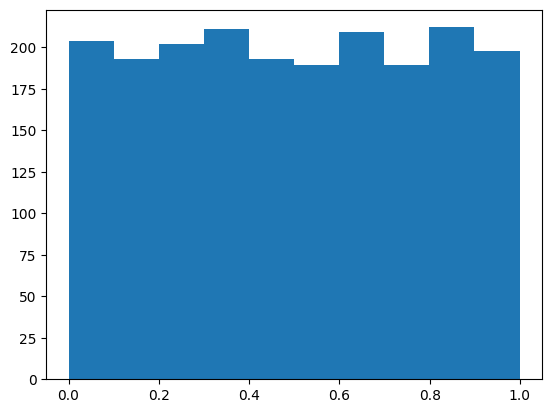

In [ ]:
import matplotlib.pyplot as plt
plt.hist(list_u)
print(np.mean(list_u), expected)
print(np.var(list_u), variance)



In [37]:
# x = stats.norm.rvs(n, mu)
stats.norm.rvs(loc=mu, scale=sigma, size=n)

array([ 2.14533957,  1.41451838,  1.763409  , -0.33232762,  0.2957468 ,
        1.05686925,  0.17537882, -1.5321487 ,  0.55547607])